In [1]:
from src.backend import TorchBackend
from src.model import Rectangle, Ellipse, Material, Lattice

import torch
import matplotlib.pyplot as plt

In [2]:
%%bash
nvidia-smi

Wed Jan 21 20:31:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:41:00.0 Off |                  Off |
|  0%   44C    P8             31W /  480W |      54MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

epsilon_xy shape: torch.Size([2, 3, 3, 501, 501])
mu_xy shape: torch.Size([2, 3, 3, 501, 501])
Error: 2.8559611786264175e-05


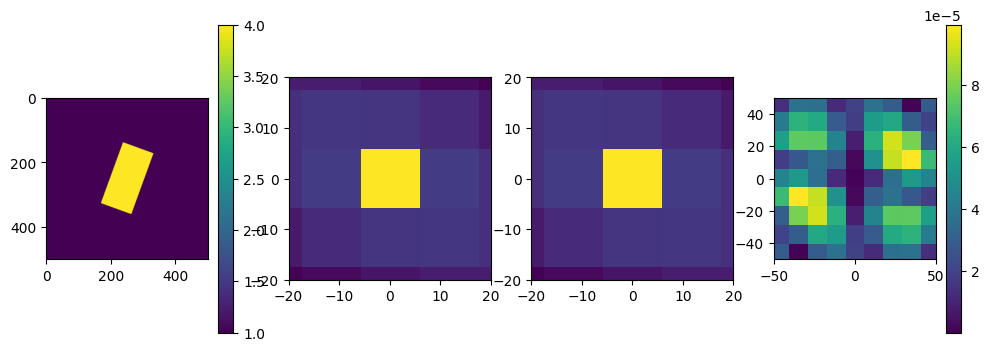

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

period = (500, 500)
grid = (501, 501)
M = 21
N = 21
lattice = Lattice(period=period, grid=grid, M=M, N=N)

center = torch.nn.Parameter(torch.tensor([0.0, 0.0]), requires_grad=True)
size = torch.nn.Parameter(torch.tensor([200.0, 100.0]), requires_grad=True)
epsilon = torch.nn.Parameter(torch.tensor([4.0,  4]), requires_grad=True)
epsilon_bg = torch.nn.Parameter(torch.tensor(1.0), requires_grad=True)

mat = Material(backend, epsilon)
mat_bg = Material(backend, epsilon_bg)

obj = Rectangle(center=center, size=size, angle=-20.0*torch.pi/180, material=mat, soft_mask=False, smoothness=0.001)


epsilon_xy = obj.epsilon_xy(backend, lattice, mat_bg)
mu_xy = obj.mu_xy(backend, lattice, mat_bg)
epsilon_mn = obj.epsilon_mn(backend, lattice, mat_bg, closed_form=True)
mu_mn = obj.mu_mn(backend, lattice, mat_bg, closed_form=True)
epsilon_f = obj.epsilon_mn(backend, lattice, mat_bg, closed_form=False)
print("epsilon_xy shape:", epsilon_xy.shape)
print("mu_xy shape:", mu_xy.shape)

plt.figure(figsize=(12,4))

plt.subplot(141)
plt.imshow(epsilon_xy[1,0,0].cpu().detach().numpy().real)
plt.colorbar()

plt.subplot(142)
plt.imshow(backend.abs(epsilon_f[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.subplot(143)
plt.imshow(backend.abs(epsilon_mn[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.subplot(144)
plt.imshow(backend.abs(epsilon_mn[1,0,0] - epsilon_f[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.colorbar()

error = torch.sqrt(torch.mean(backend.abs((epsilon_mn[1,1,1] - epsilon_f[1,1,1])**2)))
print(f'Error: {error}')

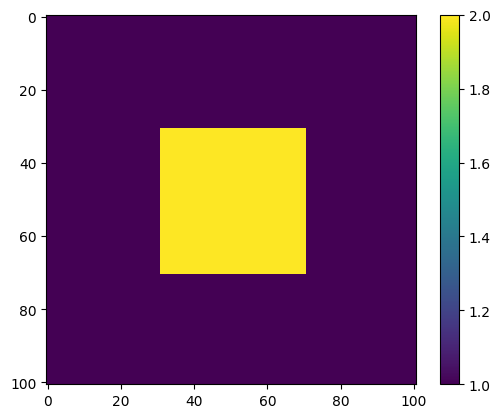

In [17]:
bitmap = Bitmap(backend, lattice, rect.bitmap, material=mat)

epsilon_xy = bitmap.epsilon_xy(mat_bg)
mu_xy = bitmap.mu_xy(mat_bg)

plt.imshow(epsilon_xy[1,1,1].cpu().detach().numpy().real)
plt.colorbar()

epsilon_xy shape: torch.Size([2, 3, 3, 101, 101])
mu_xy shape: torch.Size([2, 3, 3, 101, 101])
Error: 0.0002830599462756469


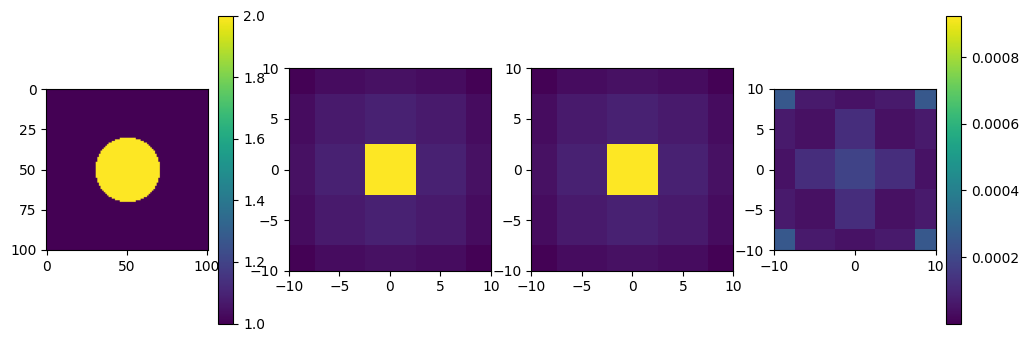

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)
backend2 = TorchBackend(device=device, dtype=dtype)

period = (500, 500)
grid = (101, 101)
lattice = Lattice(period=period, grid=grid)

wavelength = torch.nn.Parameter(torch.tensor([500.0, 600.0, 700.0]), requires_grad=True)  # in nm
theta_inc = torch.nn.Parameter(torch.tensor([30.0, 40.0, 50.0, 60.0]) * torch.pi / 180, requires_grad=True)  # in radians
phi_inc = torch.nn.Parameter(torch.tensor([45.0, 55.0, 65.0]) * torch.pi / 180, requires_grad=True)  # in radians
src = Source(backend, wavelength=wavelength, theta=theta_inc, phi=phi_inc)

center = torch.nn.Parameter(torch.tensor([0.0, 0.0]), requires_grad=True)
size = torch.nn.Parameter(torch.tensor([200.0, 200.0]), requires_grad=True)
epsilon = torch.nn.Parameter(torch.tensor([4.0,  2]), requires_grad=True)
epsilon_bg = torch.nn.Parameter(torch.tensor(1.0), requires_grad=True)

mat = Material(backend, epsilon)
mat_bg = Material(backend, epsilon_bg)

ell = Ellipse(backend, lattice, center=center, size=size, angle=0.0*torch.pi/180, material=mat, soft_mask=False, smoothness=0.001)

epsilon_xy = ell.epsilon_xy(mat_bg)
mu_xy = ell.mu_xy(mat_bg)
epsilon_mn = ell.epsilon_mn(M=(grid[0]-1)//2, N=(grid[1]-1)//2, mat_bg=mat_bg)
mu_mn = ell.mu_mn(M=(grid[0]-1)//2, N=(grid[1]-1)//2, mat_bg=mat_bg)
epsilon_f = backend.fft2(epsilon_xy, dim=(-2, -1)) / (lattice.grid[0] * lattice.grid[1])
epsilon_f_shifted = backend.fftshift(epsilon_f, dim=(-2, -1))
print("epsilon_xy shape:", epsilon_xy.shape)
print("mu_xy shape:", mu_xy.shape)

plt.figure(figsize=(12,4))

plt.subplot(141)
plt.imshow(epsilon_xy[1,0,0].cpu().detach().numpy().real)
plt.colorbar()

plt.subplot(142)
plt.imshow(backend.abs(epsilon_f_shifted[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-10, 10)
plt.ylim(-10, 10)

plt.subplot(143)
plt.imshow(backend.abs(epsilon_mn[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-10, 10)
plt.ylim(-10, 10)

plt.subplot(144)
plt.imshow(backend.abs(epsilon_mn[1,0,0] - epsilon_f_shifted[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.colorbar()

error = torch.sqrt(torch.mean(backend.abs((epsilon_mn[1,1,1] - epsilon_f_shifted[1,1,1])**2)))
print(f'Error: {error}')

epsilon_xy shape: torch.Size([2, 3, 3, 101, 101])
epsilon_mn shape: torch.Size([2, 3, 3, 101, 101])
mu_xy shape: torch.Size([2, 3, 3, 101, 101])
Error: 0.0002926418594724337


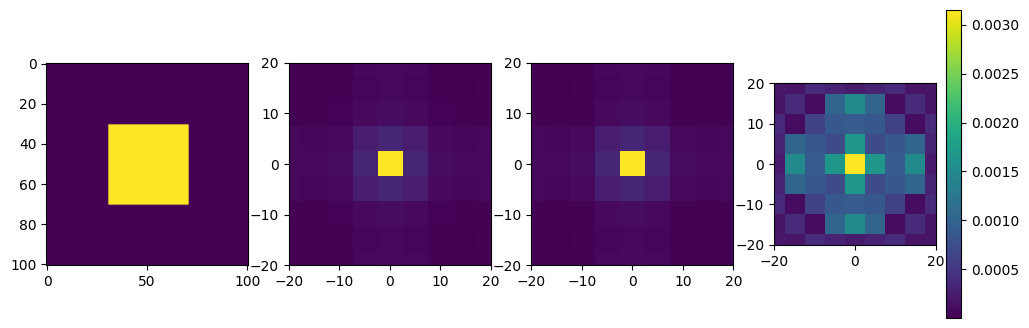

In [19]:
layer = Layer(rect, thickness=300.0, material_bg=mat_bg)

epsilon_xy = layer.epsilon_xy()
mu_xy = layer.mu_xy()
epsilon_mn = layer.epsilon_mn(M=(grid[0]-1)//2, N=(grid[1]-1)//2)
mu_mn = layer.mu_mn(M=(grid[0]-1)//2, N=(grid[1]-1)//2)
epsilon_f = layer.epsilon_mn(M=(grid[0]-1)//2, N=(grid[1]-1)//2, use_closed_form=False)
print("epsilon_xy shape:", epsilon_xy.shape)
print("epsilon_mn shape:", epsilon_mn.shape)
print("mu_xy shape:", mu_xy.shape)

plt.figure(figsize=(12,4))

plt.subplot(141)
plt.imshow(epsilon_xy[1,0,0].cpu().detach().numpy().real)

plt.subplot(142)
plt.imshow(backend.abs(epsilon_f[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.subplot(143)
plt.imshow(backend.abs(epsilon_mn[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.subplot(144)
plt.imshow(backend.abs(epsilon_mn[1,0,0] - epsilon_f[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.colorbar()

error = torch.sqrt(torch.mean(backend.abs((epsilon_mn[1,1,1] - epsilon_f[1,1,1])**2)))
print(f'Error: {error}')

epsilon_xy shape: torch.Size([2, 3, 3, 501, 501])
mu_xy shape: torch.Size([2, 3, 3, 501, 501])
Error: 2.9838235315713622e-05


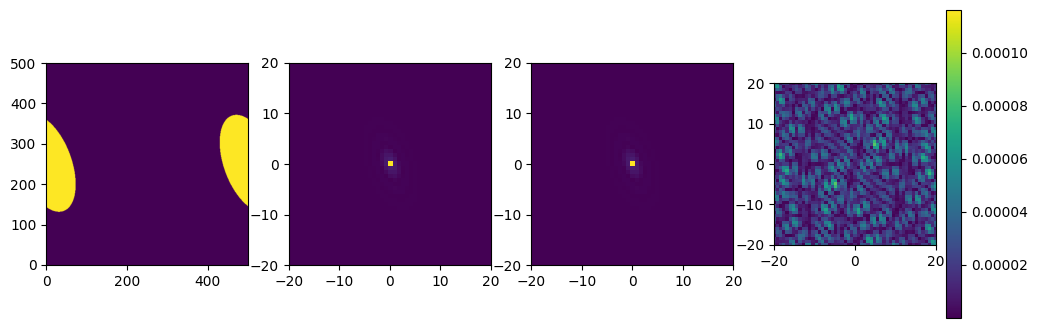

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

period = (400, 400)
grid = (501, 501)
lattice = Lattice(period=period, grid=grid)

center = torch.nn.Parameter(torch.tensor([200.0, 0.0]), requires_grad=True)
size = torch.nn.Parameter(torch.tensor([100.0, 200.0]), requires_grad=True)
epsilon = torch.nn.Parameter(torch.tensor([4.0,  2]), requires_grad=True)
epsilon_bg = torch.nn.Parameter(torch.tensor(1.0), requires_grad=True)

mat = Material(backend, epsilon)
mat_bg = Material(backend, epsilon_bg)

ell = Ellipse(backend, lattice, center=center, size=size, angle=20.0*torch.pi/180, material=mat, soft_mask=False, smoothness=0.001)

layer = Layer(ell, thickness=300.0, material_bg=mat_bg)

epsilon_xy = layer.epsilon_xy()
mu_xy = layer.mu_xy()
epsilon_mn = layer.epsilon_mn(M=(grid[0]-1)//2, N=(grid[1]-1)//2)
mu_mn = layer.mu_mn(M=(grid[0]-1)//2, N=(grid[1]-1)//2)
epsilon_f = layer.epsilon_mn(M=(grid[0]-1)//2, N=(grid[1]-1)//2, use_closed_form=False)
print("epsilon_xy shape:", epsilon_xy.shape)
print("mu_xy shape:", mu_xy.shape)

plt.figure(figsize=(12,4))

plt.subplot(141)
plt.imshow(epsilon_xy[1,0,0].cpu().detach().numpy().real.T, origin='lower')

plt.subplot(142)
plt.imshow(backend.abs(epsilon_f[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.subplot(143)
plt.imshow(backend.abs(epsilon_mn[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.subplot(144)
plt.imshow(backend.abs(epsilon_mn[1,0,0] - epsilon_f[1,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.colorbar()

error = torch.sqrt(torch.mean(backend.abs((epsilon_mn[1,1,1] - epsilon_f[1,1,1])**2)))
print(f'Error: {error}')

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

period = (500, 500)
grid = (501, 501)
lattice = Lattice(period=period, grid=grid)

wavelength = torch.nn.Parameter(torch.tensor([500.0, 600.0, 700.0]), requires_grad=True)  # in nm
theta_inc = torch.nn.Parameter(torch.tensor([30.0, 40.0, 50.0, 60.0]) * torch.pi / 180, requires_grad=True)  # in radians
phi_inc = torch.nn.Parameter(torch.tensor([45.0, 55.0, 65.0]) * torch.pi / 180, requires_grad=True)  # in radians
src = Source(backend, wavelength=wavelength, theta=theta_inc, phi=phi_inc)

center = torch.nn.Parameter(torch.tensor([0.0, 0.0]), requires_grad=True)
size = torch.nn.Parameter(torch.tensor([200.0, 200.0]), requires_grad=True)
epsilon = torch.nn.Parameter(torch.tensor([4.0,  2]), requires_grad=True)
epsilon_bg = torch.nn.Parameter(torch.tensor(1.0), requires_grad=True)

mat = Material(backend, epsilon)
mat_bg = Material(backend, epsilon_bg)

rect = Rectangle(backend, lattice, center=center, size=size, angle=45.0*torch.pi/180, material=mat, soft_mask=False, smoothness=0.001)
layer = Layer(ell, thickness=300.0, material_bg=mat_bg)

M = 11
N = 11
epsilon_mn = layer.epsilon_mn(2*M, 2*N)[:,0,0,:]

M2 = 2*M + 1
N2 = 2*N + 1

eps = torch.zeros(1, M2, N2, dtype=torch.complex64)
eps[0, M, N] = 1.0  # center = DC term


Index map shapes: torch.Size([377, 377]) torch.Size([377, 377])


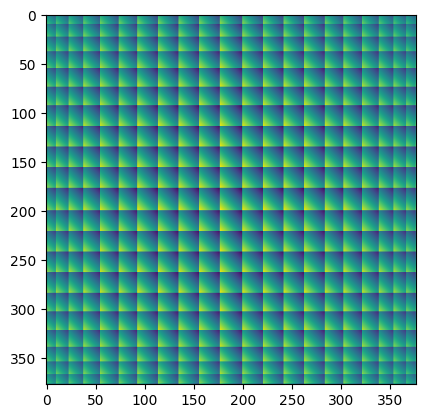

In [12]:
from src.compute import build_index_map, toeplitz_2d

device = torch.device("cpu" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
backend = TorchBackend(device=device, dtype=dtype)

M = 11
N = 11

dm_map, dn_map = build_index_map(backend, M, N, circular=True)
print("Index map shapes:", dm_map.shape, dn_map.shape)

plt.imshow(dn_map.cpu().detach().numpy())

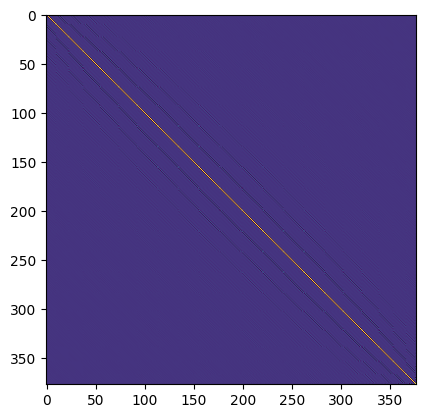

In [13]:
epsilon_mn = layer.epsilon_mn(2*M, 2*N)[:,0,0,:]
T = toeplitz_2d(backend, epsilon_mn, dm_map, dn_map)

plt.imshow((T[0].real).cpu().detach())
# plt.xlim(600, 1000)
# plt.ylim(600, 1000)